In [20]:
import random
from typing import Sequence

import matplotlib.pyplot as plt
import numpy
import pandas
from deap import algorithms
from deap import base, creator, tools
from scipy.stats import pointbiserialr
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import roc_auc_score

# PREPARATION

In [21]:
# Define random seeds for reproducibility
SEED: int = 42
random.seed(SEED)
numpy.random.seed(SEED)

In [22]:
# Constants
#CSV_TRAIN_PATH: str = "diabetes/diabetes_preprocessed_train_data.csv"
#CSV_TEST_PATH: str = "diabetes/diabetes_preprocessed_test_data.csv"
#TARGET_COLUMN: str = "Outcome"

CSV_TRAIN_PATH: str = "readmit/readmit_130_hospitals_preprocessed_train_data.csv"
CSV_TEST_PATH: str = "readmit/readmit_130_hospitals_preprocessed_test_data.csv"
TARGET_COLUMN: str = "target_readmitted"

# Bigger population -> bigger search space
POP_SIZE: int = 200
# Bigger generation number -> bigger convergence
NGEN: int = 100
# Crossing probability
CXPB: float = 0.5
# Mutation probability
MUTPB: float = 0.2

# Use ROC-AUC instead of PR-AUC
USE_ROC_AUC: bool = True

In [23]:
# Load train set
df_train: pandas.DataFrame = pandas.read_csv(CSV_TRAIN_PATH)

# Split data into training and validation sets
y: pandas.Series = df_train[TARGET_COLUMN]
X: pandas.DataFrame = df_train.drop(columns=[TARGET_COLUMN])
X_train, X_validation, y_train, y_validation = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

feature_names: list[str] = list(X.columns)

In [24]:
# Load test set
df_test: pandas.DataFrame = pandas.read_csv(CSV_TEST_PATH)

y_test: pandas.Series = df_test[TARGET_COLUMN]
X_test: pandas.DataFrame = df_test.drop(columns=[TARGET_COLUMN])

In [25]:
# Scale dataset based on train set
scaler: StandardScaler = StandardScaler()
X_train_scaled: numpy.ndarray = scaler.fit_transform(X_train)
X_validation_scaled: numpy.ndarray = scaler.transform(X_validation)
X_test_scaled: numpy.ndarray = scaler.transform(X_test)

In [26]:
# Calculate Point-biserial correlation coefficients (target value is binary and the input variables are continuous)
correlation_between_target_and_features: pandas.Series = pandas.Series(dtype=float)

for column in X_train.columns:
    if X_train[column].nunique() <= 2:
        # Fir binary variables, calculate Matthews correlation coefficient
        correlation: float = matthews_corrcoef(y_train, X_train[column])
    else:
        # For continuous variables, calculate Point-biserial correlation
        correlation, _ = pointbiserialr(y_train, X_train[column])

    correlation_between_target_and_features[column] = correlation

# MULTI OBJECTIVE

In [27]:
def coefficient_sign_score(coefficients: dict[str, float], corr_series: pandas.Series,
                           zero_tol: float = 1e-12) -> float:
    """
    Calculate the coefficient sign consistency score.

    Parameters:
        coefficients (dict[str, float]): Coefficients of the model.
        corr_series (pandas.Series): Pearson correlation coefficients.
        zero_tol (float): Tolerance for considering a value as zero.

    Returns:
        float: Coefficient sign consistency score.
    """
    penalties: float = 0.0
    total: int = len(coefficients)

    if total == 0:
        return 0.0

    for feature_name, coefficient in coefficients.items():
        correlation: float = corr_series[feature_name]

        if numpy.isnan(correlation):
            penalties += 1.0
            continue

        check: float = correlation * coefficient

        if numpy.isclose(check, 0.0, atol=zero_tol) or check < 0:
            penalties += 1.0

    return 1.0 - penalties / total

In [28]:
def evaluate_multi(individual: Sequence[int]) -> tuple[float, float]:
    if sum(individual) == 0:
        return 0.0, 0.0

    cols: numpy.ndarray = numpy.where(numpy.array(individual) == 1)[0]

    X_train_reduced: numpy.ndarray = X_train_scaled[:, cols]
    X_validation_reduced: numpy.ndarray = X_validation_scaled[:, cols]

    model: LogisticRegression = LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        max_iter=1000,
        random_state=SEED
    )

    model.fit(X_train_reduced, y_train)

    probs: numpy.ndarray = model.predict_proba(X_validation_reduced)[:, 1]

    # Calculate ROC-AUC or PR-AUC on validation set
    if USE_ROC_AUC:
        auc_score: float = roc_auc_score(y_validation, probs)
    else:
        auc_score: float = average_precision_score(y_validation, probs)

    # Calculate coefficient sign consistency score
    coef_dict: dict[str, float] = {
        feature_names[i]: model.coef_[0][j]
        for j, i in enumerate(cols)
    }
    sign_score: float = coefficient_sign_score(coef_dict, correlation_between_target_and_features)

    return auc_score, sign_score

In [29]:
if "FitnessMulti" not in creator.__dict__:
    creator.create("FitnessMulti", base.Fitness, weights=(1.0, 1.0))

if "Individual" not in creator.__dict__:
    creator.create("Individual", list, fitness=creator.FitnessMulti)

toolbox: base.Toolbox = base.Toolbox()

toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register(
    "individual",
    tools.initRepeat,
    creator.Individual,
    toolbox.attr_bool,
    n=X_train.shape[1],
)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", evaluate_multi)
toolbox.register("mate", tools.cxUniform, indpb=0.5)
toolbox.register("mutate", tools.mutFlipBit, indpb=1.0 / len(X_train.columns))
toolbox.register("select", tools.selNSGA2)

In [30]:
pop: list[creator.Individual] = toolbox.population(n=POP_SIZE)

# Initial evaluation
invalid: list[creator.Individual] = [ind for ind in pop if not ind.fitness.valid]
fitnesses: list[tuple[float, float]] = list(map(toolbox.evaluate, invalid))
for ind, fit in zip(invalid, fitnesses):
    ind.fitness.values = fit

# Crowding distance assignment
pop: list[creator.Individual] = toolbox.select(pop, len(pop))  # crowding assignment

# Pareto archive
hof: tools.ParetoFront = tools.ParetoFront()
hof.update(pop)

# Genetic algorithm
for gen in range(NGEN):
    # Binary tournament selection (NSGA-II)
    offspring: list[creator.Individual] = tools.selTournamentDCD(pop, len(pop))
    offspring = [toolbox.clone(ind) for ind in offspring]

    # Crossover
    for ind1, ind2 in zip(offspring[::2], offspring[1::2]):
        if random.random() <= CXPB:
            toolbox.mate(ind1, ind2)
            del ind1.fitness.values
            del ind2.fitness.values

    # Mutation
    for mutant in offspring:
        if random.random() <= MUTPB:
            toolbox.mutate(mutant)
            del mutant.fitness.values

    # Fitness evaluation
    invalid: list[creator.Individual] = [ind for ind in offspring if not ind.fitness.valid]
    fitnesses: list[tuple[float, float]] = list(map(toolbox.evaluate, invalid))
    for ind, fit in zip(invalid, fitnesses):
        ind.fitness.values = fit

    # Combine parents + offspring
    combined: list[creator.Individual] = pop + offspring

    # NSGA-II survival selection
    pop: list[creator.Individual] = toolbox.select(pop + offspring, POP_SIZE)

    # Update global Pareto archive
    hof.update(pop)

    print(f"Generation {gen + 1} done | Pareto size: {len(hof)}")

Generation 1 done | Pareto size: 4
Generation 2 done | Pareto size: 5
Generation 3 done | Pareto size: 7
Generation 4 done | Pareto size: 9
Generation 5 done | Pareto size: 10
Generation 6 done | Pareto size: 7
Generation 7 done | Pareto size: 10
Generation 8 done | Pareto size: 13
Generation 9 done | Pareto size: 11
Generation 10 done | Pareto size: 7
Generation 11 done | Pareto size: 9
Generation 12 done | Pareto size: 6
Generation 13 done | Pareto size: 6
Generation 14 done | Pareto size: 12
Generation 15 done | Pareto size: 12
Generation 16 done | Pareto size: 14
Generation 17 done | Pareto size: 13
Generation 18 done | Pareto size: 13
Generation 19 done | Pareto size: 11
Generation 20 done | Pareto size: 11
Generation 21 done | Pareto size: 12
Generation 22 done | Pareto size: 11
Generation 23 done | Pareto size: 10
Generation 24 done | Pareto size: 11
Generation 25 done | Pareto size: 13
Generation 26 done | Pareto size: 15
Generation 27 done | Pareto size: 9
Generation 28 done |

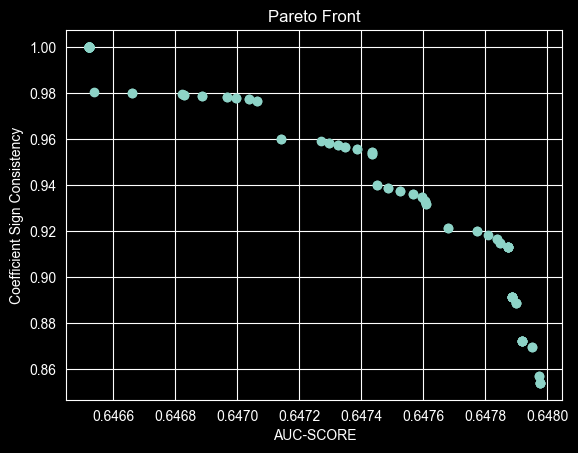

In [31]:
pareto: list[creator.Individual] = tools.sortNondominated(pop, len(pop), first_front_only=True)[0]

auc_values: list[float] = [ind.fitness.values[0] for ind in pareto]
sign_values: list[float] = [ind.fitness.values[1] for ind in pareto]

plt.scatter(auc_values, sign_values)
plt.xlabel("AUC-SCORE")
plt.ylabel("Coefficient Sign Consistency")
plt.title("Pareto Front")
plt.show()

In [32]:
# Convert Pareto front fitness values to numpy array
points: numpy.ndarray = numpy.array([ind.fitness.values for ind in pareto])

# Extreme points
max_auc_index: int = int(numpy.argmax(points[:, 0]))
max_sign_index: int = int(numpy.argmax(points[:, 1]))

max_auc_ind: creator.Individual = pareto[max_auc_index]
max_sign_ind: creator.Individual = pareto[max_sign_index]

# Knee-point calculation
p1: numpy.ndarray = points[max_auc_index]
p2: numpy.ndarray = points[max_sign_index]

if numpy.allclose(p1, p2):
    knee_index: int = 0
else:
    line_vector: numpy.ndarray = p2 - p1
    line_vector = line_vector / numpy.linalg.norm(line_vector)

    distances: list[float] = []

    for p in points:
        vector: numpy.ndarray = p - p1
        projection: numpy.ndarray = numpy.dot(vector, line_vector) * line_vector
        orthogonal: numpy.ndarray = vector - projection
        distances.append(float(numpy.linalg.norm(orthogonal)))

    knee_index: int = int(numpy.argmax(distances))

knee_ind: creator.Individual = pareto[knee_index]

# Helper function to extract info
def extract_info(individual) -> tuple[float, float, int, numpy.ndarray]:
    cols: numpy.ndarray = numpy.where(numpy.array(individual) == 1)[0]
    auc: float = individual.fitness.values[0]
    sign_consistency: float = individual.fitness.values[1]
    n_features: int = len(cols)
    return auc, sign_consistency, n_features, cols

auc1, sign1, nf1, cols1 = extract_info(max_auc_ind)
auc2, sign2, nf2, cols2 = extract_info(max_sign_ind)
auc3, sign3, nf3, cols3 = extract_info(knee_ind)

print("\n=== Pareto Front Model Comparison On Validation Set ===\n")

print("1) Maximum AUC model")
print(f"AUC on validation set: {auc1:.4f}")
print(f"Sign consistency on validation set: {sign1:.4f}")
print(f"Number of features: {nf1}")

print("\n2) Maximum Sign Consistency model")
print(f"AUC on validation set: {auc2:.4f}")
print(f"Sign consistency on validation set: {sign2:.4f}")
print(f"Number of features: {nf2}")

print("\n3) Knee-point model (balanced solution)")
print(f"AUC on validation set: {auc3:.4f}")
print(f"Sign consistency on validation set: {sign3:.4f}")
print(f"Number of features: {nf3}")


=== Pareto Front Model Comparison On Validation Set ===

1) Maximum AUC model
AUC on validation set: 0.6480
Sign consistency on validation set: 0.8542
Number of features: 48

2) Maximum Sign Consistency model
AUC on validation set: 0.6465
Sign consistency on validation set: 1.0000
Number of features: 42

3) Knee-point model (balanced solution)
AUC on validation set: 0.6478
Sign consistency on validation set: 0.9167
Number of features: 48


In [33]:
# Calculate the final results on the test set
def evaluate_on_test(cols) -> tuple[float, float]:
    X_train_reduced: numpy.ndarray = X_train_scaled[:, cols]
    X_test_reduced: numpy.ndarray = X_test_scaled[:, cols]

    model: LogisticRegression = LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        max_iter=1000,
        random_state=SEED
    )

    model.fit(X_train_reduced, y_train)

    test_probs: numpy.ndarray = model.predict_proba(X_test_reduced)[:, 1]
    roc_auc: float = roc_auc_score(y_test, test_probs)
    pr_auc: float = average_precision_score(y_test, test_probs)

    return roc_auc, pr_auc

roc_auc1_t, pr_auc1_t = evaluate_on_test(cols1)
roc_auc2_t, pr_auc2_t = evaluate_on_test(cols2)
roc_auc3_t, pr_auc3_t = evaluate_on_test(cols3)

print("\n=== Test Set Model Comparison ===\n")

print("1) Maximum AUC model")
print(f"ROC-AUC on test set: {roc_auc1_t:.4f}")
print(f"PR-AUC on test set: {pr_auc1_t:.4f}")
print(f"Number of features: {nf1}")

print("\n2) Maximum Sign Consistency model")
print(f"ROC-AUC on test set: {roc_auc2_t:.4f}")
print(f"PR-AUC on test set: {pr_auc2_t:.4f}")
print(f"Number of features: {nf2}")

print("\n3) Knee-point model (balanced solution)")
print(f"ROC-AUC on test set: {roc_auc3_t:.4f}")
print(f"PR-AUC on test set: {pr_auc3_t:.4f}")
print(f"Number of features: {nf3}")


=== Test Set Model Comparison ===

1) Maximum AUC model
ROC-AUC on test set: 0.6401
PR-AUC on test set: 0.1990
Number of features: 48

2) Maximum Sign Consistency model
ROC-AUC on test set: 0.6396
PR-AUC on test set: 0.1983
Number of features: 42

3) Knee-point model (balanced solution)
ROC-AUC on test set: 0.6404
PR-AUC on test set: 0.1987
Number of features: 48


# SINGLE OBJECTIVE

In [34]:
# Reset random seeds for reproducibility
random.seed(SEED)
numpy.random.seed(SEED)

In [35]:
def evaluate_single(individual: Sequence[int]) -> tuple[float]:
    if sum(individual) == 0:
        return (0.0,)

    cols: list[int] = [i for i, bit in enumerate(individual) if bit]

    X_train_reduced: numpy.ndarray = X_train_scaled[:, cols]
    X_validation_reduced: numpy.ndarray = X_validation_scaled[:, cols]

    model: LogisticRegression = LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        max_iter=1000,
        random_state=SEED
    )

    model.fit(X_train_reduced, y_train)

    probs: numpy.ndarray = model.predict_proba(X_validation_reduced)[:, 1]

    if USE_ROC_AUC:
        auc_score: float = roc_auc_score(y_validation, probs)
    else:
        auc_score: float = average_precision_score(y_validation, probs)

    return (auc_score,)

In [36]:
if "FitnessSingle" not in creator.__dict__:
    creator.create("FitnessSingle", base.Fitness, weights=(1.0,))

if "IndividualSingle" not in creator.__dict__:
    creator.create("IndividualSingle", list, fitness=creator.FitnessSingle)

In [37]:
toolbox: base.Toolbox = base.Toolbox()

toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register(
    "individual",
    tools.initRepeat,
    creator.IndividualSingle,
    toolbox.attr_bool,
    n=X_train.shape[1],
)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", evaluate_single)
toolbox.register("mate", tools.cxUniform, indpb=0.5)
toolbox.register("mutate", tools.mutFlipBit, indpb=1.0 / len(X_train.columns))

toolbox.register("select", tools.selTournament, tournsize=3)

pop: list[creator.IndividualSingle] = toolbox.population(n=POP_SIZE)
hof: tools.HallOfFame = tools.HallOfFame(1)

stats: tools.Statistics = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("max", numpy.max)

pop, logbook = algorithms.eaSimple(
    pop,
    toolbox,
    cxpb=0.5,
    mutpb=0.2,
    ngen=NGEN,
    stats=stats,
    halloffame=hof,
    verbose=True
)

best_individual: creator.IndividualSingle = hof[0]
best_cols: list[int] = [i for i, bit in enumerate(best_individual) if bit == 1]

selected_feature_names: list[str] = [feature_names[i] for i in best_cols]
selected_feature_names.sort()
print("Selected features:", selected_feature_names)

gen	nevals	max     
0  	200   	0.636346
1  	122   	0.639142
2  	116   	0.639142
3  	132   	0.640024
4  	123   	0.641029
5  	134   	0.641281
6  	121   	0.642085
7  	133   	0.644187
8  	120   	0.644357
9  	126   	0.644357
10 	116   	0.644762
11 	114   	0.645343
12 	122   	0.645784
13 	123   	0.64627 
14 	128   	0.646119
15 	120   	0.646393
16 	118   	0.64676 
17 	115   	0.646849
18 	103   	0.646931
19 	125   	0.647199
20 	115   	0.647199
21 	121   	0.647192
22 	126   	0.64732 
23 	110   	0.647323
24 	109   	0.647341
25 	113   	0.647412
26 	121   	0.647429
27 	114   	0.647448
28 	119   	0.647496
29 	124   	0.647526
30 	119   	0.647603
31 	124   	0.64762 
32 	129   	0.647706
33 	115   	0.647703
34 	114   	0.647709
35 	123   	0.647735
36 	117   	0.647821
37 	121   	0.647793
38 	128   	0.64782 
39 	112   	0.647849
40 	116   	0.647877
41 	121   	0.647877
42 	120   	0.647892
43 	115   	0.647908
44 	119   	0.647908
45 	124   	0.647908
46 	133   	0.64791 
47 	115   	0.64791 
48 	126   	0.647931


In [38]:
# Calculate the final results on the test set
X_train_reduced: numpy.ndarray = X_train_scaled[:, best_cols]
X_test_reduced: numpy.ndarray = X_test_scaled[:, best_cols]

final_model: LogisticRegression = LogisticRegression(
    penalty="l2",
    solver="lbfgs",
    max_iter=1000,
    random_state=SEED
)

final_model.fit(X_train_reduced, y_train)

test_probs: numpy.ndarray = final_model.predict_proba(X_test_reduced)[:, 1]
test_pr_auc: float = average_precision_score(y_test, test_probs)
test_roc_auc: float = roc_auc_score(y_test, test_probs)

print("\n=== Test Set Model Comparison ===\n")

print(f"ROC-AUC on test set: {test_roc_auc:.4f}")
print(f"PR-AUC on test set: {test_pr_auc:.4f}")
print(f"Number of features: {len(best_cols)}")


=== Test Set Model Comparison ===

ROC-AUC on test set: 0.6407
PR-AUC on test set: 0.1992
Number of features: 53
